**Charger le dataset nettoyé & poser le problème ML**

Comprendre que le Machine Learning commence par un problème bien formulé, pas par un algorithme.

In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dataset_energie_batiments_nettoye_atelier1.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   building_id             1200 non-null   int64  
 1   surface_m2              1200 non-null   float64
 2   year_built              1200 non-null   int64  
 3   building_type           1200 non-null   object 
 4   city                    1200 non-null   object 
 5   energy_consumption_kwh  1200 non-null   float64
 6   co2_emissions_kg        1200 non-null   float64
 7   energy_class            1200 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 75.1+ KB


**ÉTAPE CLÉ — Formuler le problème de ML**

>Choisir la variable cible (Y)

>Décision métier (pas technique).

🧩 Définir la cible (Y) et les variables explicatives (X)

Qu’est-ce qu’on cherche à prédire ?

Est-ce une valeur continue ou une classe ?

Quel usage métier derrière cette prédiction ?

In [4]:
target = "energy_consumption_kwh"

X = df.drop(columns=[target])
y = df[target]


Pourquoi cette variable ?

Est-ce une régression ou une classification ?

Que cherchons-nous à prédire concrètement ?

X = ce que le modèle UTILISE

y = ce que le modèle APPREND à prédire

**Nettoyage logique** (dernier rappel EDA)

In [5]:
X.columns

Index(['building_id', 'surface_m2', 'year_built', 'building_type', 'city',
       'co2_emissions_kg', 'energy_class'],
      dtype='object')

🧩 Sélection des variables utiles

In [6]:
X.head()

,building_id,surface_m2,year_built,building_type,city,co2_emissions_kg,energy_class
0,1,139.9,1994,Industrie,Lyon,20.9,F
1,2,114.5,1996,Industrie,Lille,62.3,E
2,3,122.5,1962,Résidentiel,Lyon,32.1,E
3,4,180.9,1971,Résidentiel,Lyon,35.1,A
4,5,110.6,1970,Résidentiel,Marseille,54.9,E


building_id est un identifiant

il n’a aucune valeur explicative

In [7]:
X = X.drop(columns=["building_id"])

Nous avons maintenant :

>un **dataset propre**

>une **variable cible claire**

>des **variables explicatives pertinentes**

>Le problème de Machine Learning est correctement posé.

🧩 ÉTAPE 2 — Séparation train / test

Si j’évalue un modèle sur les données qui ont servi à l’entraîner, je ne mesure pas sa capacité à prédire, je mesure sa capacité à mémoriser.

Import de la fonction

In [8]:
from sklearn.model_selection import train_test_split


Séparation des données

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(840, 6)
(360, 6)


70 % des données → entraînement

30 % → test

le split doit être fait AVANT :

>le scaling

>l’encodage

>toute transformation apprenante

Nous avons séparé nos données pour pouvoir
évaluer le modèle de manière honnête.

🧩 **ÉTAPE 3** Préparation des variables (numériques & catégorielles)

Les algorithmes ne comprennent que des nombres
et la préparation influence plus le résultat que le modèle lui-même.

Un algorithme de Machine Learning ne comprend
>ni les mots,

>ni les catégories,

>ni les unités.

Il ne comprend que des nombres.

🧩 ÉTAPE 3.1 — Identifier les types de variables

Séparer ce qui est :

>numérique (à mettre à l’échelle)

>catégoriel (à encoder)

In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_features, categorical_features


(Index(['surface_m2', 'year_built', 'co2_emissions_kg'], dtype='object'),
 Index(['building_type', 'city', 'energy_class'], dtype='object'))

les variables numériques ont des unités différentes

les variables catégorielles ne peuvent pas être “lues” telles quelles

Même si deux variables sont numériques,
leur échelle peut fausser l’apprentissage.

🧩 ÉTAPE 3.2 — Pourquoi le scaling est nécessaire

Si une variable varie entre 0 et 10
et une autre entre 0 et 10 000,
certains modèles donneront mécaniquement
plus d’importance à la seconde.

> Ce n’est pas un choix métier, c’est un effet mathématique.

🧩 ÉTAPE 3.3 — Pourquoi encoder les variables catégorielles

on ne peut pas donner :

>“Résidentiel”

>“École”

>“Industrie”

comme ça à un algorithme

il faut transformer en variables binaires

« Encoder ≠ ordonner. »

>>One-Hot Encoding évite de créer une fausse hiérarchie.

🧩 ÉTAPE 3.4 — Construire le préprocesseur (proprement)

Garantir que les mêmes transformations seront appliquées :

>au train

>au test

>plus tard, en production

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

Construction du préprocesseur

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


🔹 StandardScaler()

>centre les données

>met toutes les variables sur la même échelle

>indispensable pour certains modèles

🔹 OneHotEncoder(handle_unknown="ignore")

>évite les erreurs si une nouvelle catégorie apparaît

>réflexe pro (production-ready)



*Ce paramètre évite que le modèle casse quand il voit une donnée nouvelle*.

⚠️ ERREURS CLASSIQUES
❌ Encoder avant le split

>On introduit une fuite d’information (data leakage)

❌ Appliquer le scaler séparément sur train et test

>Le modèle apprend indirectement sur les données de test.

**Le pipeline évite ces erreurs**.

Nous avons maintenant défini
comment traduire nos données réelles
en données exploitables par un algorithme.

La prochaine étape consiste à
relier cette préparation au modèle lui-même.

>preprocessor → préparation

>pipeline → préparation + modèle

>pipeline = pratique professionnelle

**ÉTAPE 4** Construire le pipeline complet (préparation + modèle)


Un pipeline ML professionnel,
est indispensable, il évite les erreurs classiques.

*En pratique professionnelle, on ne sépare jamais la préparation des données du modèle de Machine Learning.*

Tout doit être exécuté dans le bon ordre,
de manière reproductible.

>Rôle du pipeline.

✔ un preprocessor (scaling + encodage)

✔ des données séparées train / test

✔ un problème ML bien posé

🧩 ÉTAPE 4.1 — Choisir le modèle (régression)


On choisit ici un RandomForestRegressor parce que :

>robuste

>peu sensible aux outliers

>fonctionne bien “out of the box”

>permet l’interprétation (feature importance)

*Ce n’est pas le meilleur modèle, c’est un bon modèle pédagogique*.

Le “meilleur” dépend :

>du problème

>des données

>des contraintes métier

>de ce qu’on cherche à optimiser

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


🧩 ÉTAPE 4.2 — Construire le pipeline complet


Garantir que :

>la préparation est faite après le split

>la même transformation est appliquée partout

>aucune fuite d’information n’est possible

In [16]:
from sklearn.pipeline import Pipeline

Construction du pipeline

In [17]:
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ]
)


🔹 L’ordre des étapes

> 1 preprocessing

> 2 model

L’ordre est critique.



*Le pipeline impose un ordre logique que l’on ne peut pas casser par erreur*.

🔹 Ce que fait pipeline.fit()



pipeline.fit(X_train, y_train) :

>le preprocessor apprend uniquement sur le train

>le modèle apprend sur les données transformées

>aucune information du test n’est utilisée

*C’est la clé contre le data leakage*.

ÉTAPE 4.3 — Entraînement du pipeline

In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['surface_m2', 'year_built', 'co2_emissions_kg'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['building_type', 'city', 'energy_class'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

À partir de maintenant,
le modèle a appris une relation entre X et y,
mais uniquement sur le jeu d’entraînement.

🧩 ÉTAPE 4.4 — Prédiction sur le jeu de test

In [19]:
y_pred = pipeline.predict(X_test)

*   Une transformation peut fuiter de l’information

*   Le pipeline empêche cette fuite

*   Il n’existe pas de meilleur modèle universel

*   RandomForest est un bon modèle pédagogique

*   Feature importance = comprendre ce que le modèle utilise




**ÉTAPE 5** Évaluation du modèle (performance & sens métier)


l’évaluation n’est pas un score, mais une capacité à juger si le modèle est utile et fiable.

Un modèle n’est pas bon parce qu’il a un bon score.

Il est bon s’il :

>généralise

>est compréhensible

>et sert le besoin métier.

🧩 ÉTAPE 5.2 — Choisir les métriques adaptées (régression)

Nous sommes dans un problème de régression
→ prédire une valeur continue (energy_consumption_kwh).

On utilise donc :

>R²

>RMSE

In [20]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² :", r2)
print("RMSE :", rmse)


R² : -0.06412592732671163
RMSE : 59.81881519054018


Comment INTERPRÉTER les métriques

🔹 R² (coefficient de détermination)

R² mesure la part de la variance de la cible expliquée par le modèle.

Repères  :

>R² ≈ 0 → le modèle n’explique rien

>R² < 0 → pire qu’une moyenne

>R² ≈ 0.6–0.8 → souvent très correct en pratique

>R² ≈ 1 → suspect (overfitting)



*Un R² parfait est souvent un signal d’alerte*.


🔹 RMSE (erreur moyenne)

Le RMSE correspond à l’erreur moyenne de prédiction, exprimée dans l’unité de la variable cible.

Ici : **kWh**

*Est-ce que cette erreur est acceptable au regard du métier ?*



Un RMSE de 10 000 kWh peut être excellent pour un site industriel,
et catastrophique pour un logement.

**Le score seul ne veut rien dire**.

🧩 ÉTAPE 5.3 — Analyse visuelle des prédictions

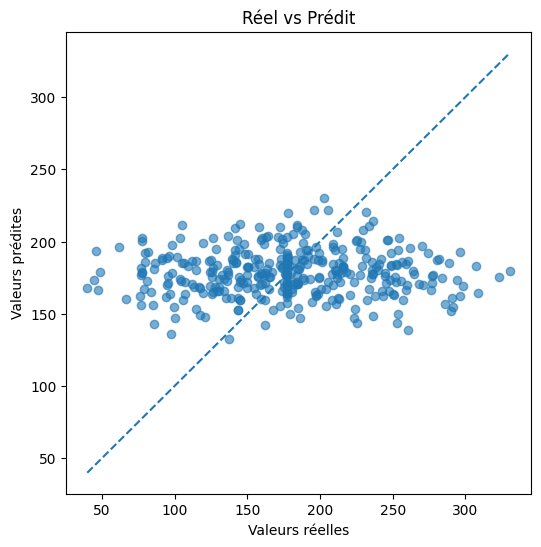

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")
plt.show()


🧩 ÉTAPE 5.4 — Interprétation : feature importance

In [22]:
import pandas as pd

feature_names = pipeline.named_steps["preprocessing"] \
    .get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)


,feature,importance
0,num__surface_m2,0.244796
2,num__co2_emissions_kg,0.218963
1,num__year_built,0.194359
10,cat__city_Marseille,0.024349
11,cat__city_Nantes,0.022737
7,cat__building_type_École,0.021920
3,cat__building_type_Bureau,0.021842
4,cat__building_type_Commerce,0.020904
8,cat__city_Lille,0.020486
14,cat__energy_class_A,0.019562


>R² = -0.064

>RMSE ≈ 59.8

>prédictions écrasées entre 150 et 200

>peu de dispersion

>pas de suivi de la diagonale


**Le modèle ne capture pas la structure du problème**.

Le code est bon, le modèle est honnête... mais il manque quelque chose ...

>usage réel du bâtiment

>nombre d’occupants

>surface chauffée réelle

>type de chauffage

>conditions climatiques

>comportement humain

**Et si on n’avait pas de variable cible** ?

Pour améliorer ce modèle :

oui, il faut plus de données

oui, il faut de meilleures variables

non, ce n’est pas juste “changer de modèle

🔥 type de chauffage

👥 nombre d’occupants

🕒 taux d’occupation

🌡️ température moyenne locale

🏠 surface réellement chauffée

🪟 qualité d’isolation réelle

⚡ équipements énergivores

📅 saisonnalité